In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math
from src.io_utils import load_csv, coerce_numeric
from src.health_class import HealthAnalyser
from src.class_plot import HealthPlot
from statsmodels.stats.power import TTestIndPower



df = coerce_numeric(load_csv("data/hsd.csv"))



In [32]:
from src.metrics import information

print(information(df))


             age   weight     height  systolic_bp  cholesterol
mean    49.42625   73.413  171.84925   149.178625      4.92915
median  50.00000   73.200  171.35000   149.400000      4.97000
min     18.00000   33.700  144.40000   106.800000      2.50000
max     90.00000  114.400  200.40000   185.900000      7.88000


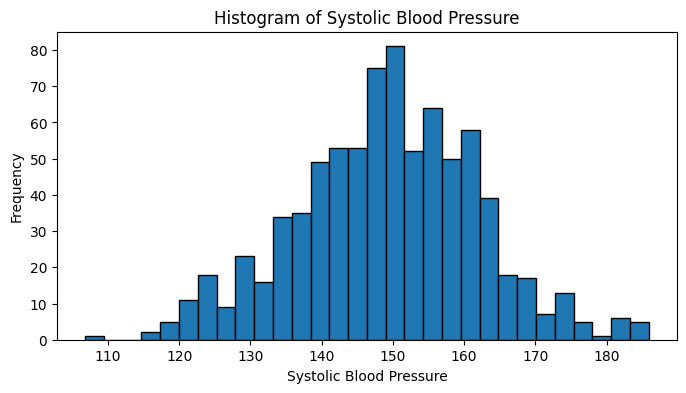

None


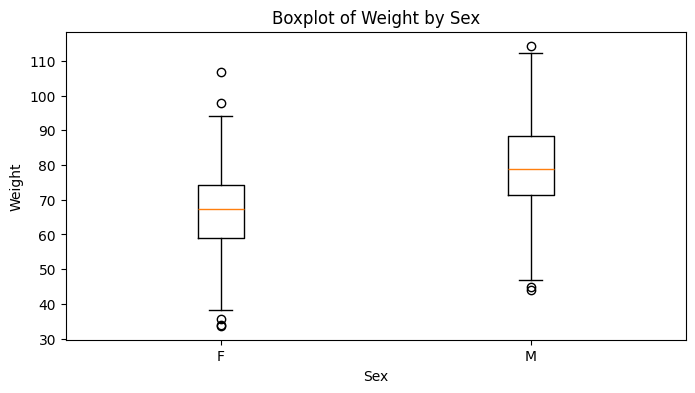

None


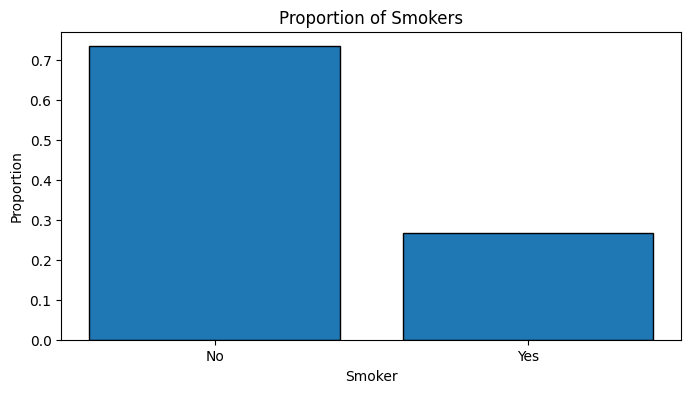

None


In [33]:
health = HealthAnalyser(df)

print(health.hist_bloodpressure())
print(health.box_weight_sex())
print(health.bar_smokers())

In [34]:
np.random.seed(123)
health.sim_disease()


Verklig andel: 0.059
Simulerad andel: 0.066
Skillnad: 0.007


En simulering med 1000 personer utförs med samma sjukdoms sanolikhet som i urvalet. Samma beräknar görs för sanolikheten på den nya datan och vi kan se en skillnad på brara 0.7% 

Konfidens intervall av blodtrycket

In [35]:
health.connfidence_interval("systolic_bp")

'CL low 148.29, CL high 150.07'

Jag anände mig av ett t test för att räkna ut ett 95% konfidens intervall eftersom det sanna std inte finns tillgänglig.

Hypotes prövning "Rökare har högre medel-blodtryck än icke-rökare.”

In [36]:
health.blood_pressure_smoker_vs_nonesmoker()

't -score 0.45, p value 0.33'

Testet ger ett värde på 0.326, viket innebär att det är ungefär 33% chans att vi ser prov som har sådan här skillnad eller mer givet att nullhypotesen är sann.
Jag använde mig av ett alpha värde 5% viket betyder att jag misslykades att avvisa noll_hypotesen efersom p värdet är större än alpha 0.05.
Eftersom p-värdet (0.326) är större än signifikansnivån α = 0.05 finns det inte tillräckligt med statistiskt stöd för att avvisa nollhypotesen.

Räknar ut power 

In [37]:
from src.metrics import smoker_power_analysis
power = smoker_power_analysis(df)

print(power)

power : 0.075


som vi kan se har jag bara en 7.5% chans att upptäcka en skillnad i systolic BP mellan rökare och ickerökare. Man brukar sätta gränsen vid 80% power viket vi ligger långt under 

In [38]:
from src.metrics import run_power_simulation
run_power_simulation(df)


Antal rökare: 213
Antal icke-rökare: 587
Sann skillnad =  0 mmHg  ->  power ≈ 0.049
Sann skillnad =  1 mmHg  ->  power ≈ 0.248
Sann skillnad =  2 mmHg  ->  power ≈ 0.603
Sann skillnad =  3 mmHg  ->  power ≈ 0.892
Sann skillnad =  4 mmHg  ->  power ≈ 0.986
Sann skillnad =  5 mmHg  ->  power ≈ 1.000


Vi börjar med att definiera två normalfördelningar som representerar de två populationerna (t.ex. rökare och icke-rökare), där båda har sina respektive standardavvikelser från den riktiga datan. Den ena populationen har ett medelvärde som är 3 mmHg högre än den andra för att motsvara den antagna sanna effekten.
Från dessa två fördelningar drar vi sedan slumpmässiga stickprov av storlek n och genomför ett Welch’s tvåstickprovstest (ttest_ind med equal_var=False). För varje iteration får vi ett t-värde och ett p-värde.
Denna process upprepas 2000 gånger. Efteråt räknar vi hur stor andel av simuleringarna som ger ett p-värde under 0,05, vilket innebär att nollhypotesen (ingen skillnad mellan grupperna) förkastas. Denna andel är en uppskattning av testets power, det vill säga sannolikheten att upptäcka en verklig skillnad på 3 mmHg givet stickprovsstorlekarna och variansen i datan.
I våra simuleringar ser vi att en sann skillnad på 3 mmHg skulle ge en power på cirka 80 %, vilket ofta används som en riktlinje för att en studie ska ha tillräcklig styrka för att kunna påvisa en effekt och därmed kunna förkasta nollhypotesen.

I vårt faktiska datamaterial uppskattas däremot powern till endast omkring 3,7 %. Detta är mycket lågt och innebär att studien har liten sannolikhet att upptäcka en eventuell verklig skillnad. Vi kan därför inte förkasta nollhypotesen, och den observerade skillnaden kan mycket väl bero på slumpen.

Detta är en linjär regression med två parametrar 

In [39]:
from src.metrics import linear_model

linreg, x, y, r2 = linear_model(df, ["age", "weight"])



intercept: 109.499
Slopes:
  age: 0.539
  weight: 0.178
R²: 0.405


Funktionen utför en linjär regression för att förutsäga systoliskt blodtryck baserat på en eller flera förklarande variabler.
Interceptet representerar skärningspunkten med y-axeln, det vill säga det förväntade systoliska blodtrycket när alla variabler är 0.
Lutningarna (koefficienterna) anger hur mycket det systoliska blodtrycket i genomsnitt förändras när en viss variabel ökar med en enhet.
Exempel:
En koefficient för ålder på 0.539 innebär att blodtrycket förväntas öka med 0.539 mmHg per års ökning i ålder, allt annat lika.
En koefficient för vikt på 0.178 innebär att blodtrycket förväntas öka med 0.178 mmHg per extra kilogram.
R²-värdet anger hur stor andel av variationen i blodtrycket som modellen kan förklara. Ett högre R² innebär att modellen bättre fångar sambandet mellan variablerna och blodtrycket.

Detta är med en parameter samt en graf av värdena 

intercept: 122.685
Slopes:
  age: 0.536
R²: 0.369


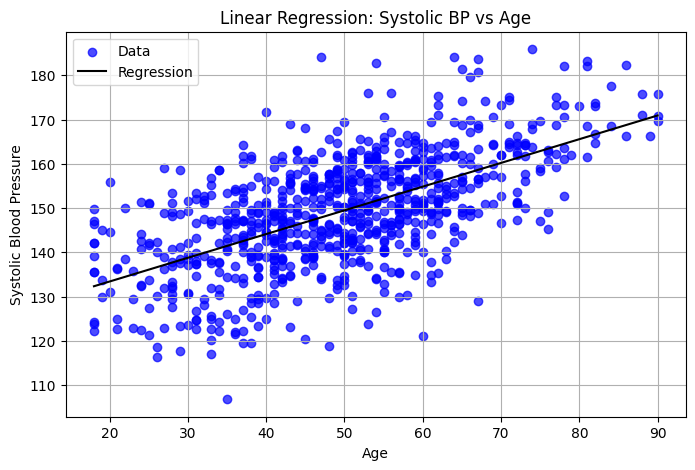

In [40]:
from src.plot_fig import plot_regression

linreg, x, y, r2 = linear_model(df, ["age"])

plot_regression(x, y , linreg)

vi kan se att ungefär 37 % av variationen i blodtryck kan förklaras av ålder och ca 41 % när vi anväder både ålder och vikt

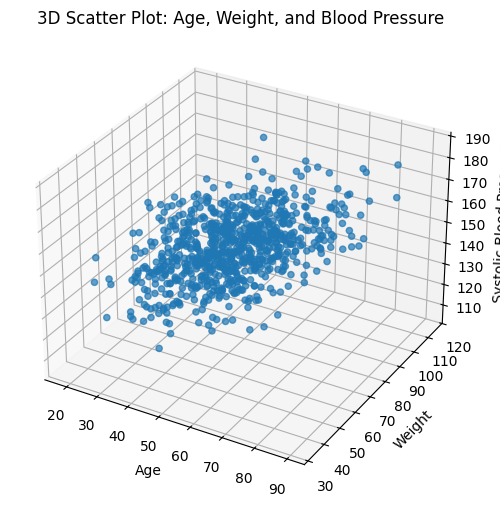

In [41]:
from src.plot_fig import plot_regression_3d

plot_regression_3d(df["age"], df["weight"], df["systolic_bp"])

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression


X = df[["age", "weight"]]
y = df["systolic_bp"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model = LinearRegression()
model.fit(X_pca, y)

print("Regression coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Variance ratio:", pca.explained_variance_ratio_)

Regression coefficients: [3.804541   7.24070322]
Intercept: 149.178625
Variance ratio: [0.50865453 0.49134547]


PCA används för att dimensionera ner datan när flera variabler används för att lättare visualisera datan,
men också för att få bort onödig information. Har man många variabler finns det stor chans att några har samma underliggande mönster. 
PCA komprimerar dessa då. Man minskar bruset. Eftersom PCA dimensionera ner datan blir modellerna sabbare vid beräkningar som tar mindre minne

scaler - dess uppgift är att standardisera variablena så allt hamnar på en skala.

Vi kommer nu få två nya komponeter PC1 och PC2 istället för (age, weight)
PC1 = variabel som fångar mest variation i datan. (Fångar så mycket information som möjligt från de två ursprungliga variablerna.)
PC2 = variabeln som fångar variation som PC1 inte förklarar (fångar den näst största variationen och är vinkelrät mot PC1)

Variance ratio är ett mått på hur mycket av den totala variationen i datan som varje PC-komponent förklarar.
PC1 = 51% och PC2 49%